# Phase 3: DQN Retirement — Detailed Report

**CME 241: Reinforcement Learning for Finance · Stanford University · Winter 2026**

---

## Executive Summary

This report documents **Stage 3** of the retirement asset allocation project: a **Deep Q-Network (DQN)** solution for dynamic asset allocation over a 35-year horizon (ages 30–65). The formulation extends Phase 2 by using **continuous wealth**, **market regimes** (bull/neutral/bear), and **switching costs**. The agent chooses among **six actions** each year (**Scheme B**: pure picks + 50/50 blends): **VFSTX** (short-term bond), **VBMFX** (total bond market), **VFINX** (equity), plus the three 50/50 pairwise blends (VFSTX+VBMFX, VFSTX+VFINX, VBMFX+VFINX). The objective is to maximize expected **CRRA utility of terminal wealth** at retirement, with **age-dependent risk aversion** (γ increases linearly from 2.0 at age 30 to 3.05 at age 65).

**Main results (5,000 evaluation episodes per policy, Scheme B — 6 actions):**
- **DQN** achieves the highest mean CRRA utility (0.4573), while **Always VFINX** achieves the highest median terminal wealth ($5.74M).
- **Glide Path** (VFINX → VBMFX → VFSTX by age) achieves the second-highest mean utility, demonstrating the value of de-risking as risk aversion increases.
- **Always VFSTX** and **Always VBMFX** underperform; **Random** (uniform over 6 actions) is comparable to Glide Path in wealth but lower in utility.

The report below provides **all parameters, formulas, and steps** required to replicate these results.

---
## 1. How to Replicate Results

**Option A (recommended):** Run `phase3_dqn_retirement.ipynb` from top to bottom. It will:
1. Set the random seed (42), load config, and download historical returns (VFINX, VBMFX, VFSTX) via `yfinance` (1990–2024).
2. Calibrate the regime transition matrix and per-regime return parameters from the VFINX return history.
3. Train the DQN for 5,000 episodes (about 2–3 minutes on CPU).
4. Evaluate all six policies for 5,000 episodes each and save figures as `fig_s3_1_training.png` through `fig_s3_7_regime_action.png`.

**Option B:** Use the exact configuration and code in this report. All hyperparameters are listed in **Section 2**; the environment and DQN logic are in `phase3_dqn_retirement.ipynb` and summarized in **Sections 3–5**.

**Dependencies:** `numpy`, `pandas`, `matplotlib`, `torch`, `yfinance`. Python 3.8+.

---
## 2. Full Configuration (Replication Parameters)

All parameters are defined in a single `Config` dataclass in `phase3_dqn_retirement.ipynb`. The values used for the reported results are below.

| Parameter | Value | Description |
|-----------|--------|-------------|
| `start_age` | 30 | First decision age |
| `retirement_age` | 65 | Terminal age |
| `initial_wealth` | 100,000 | Starting wealth ($) |
| `annual_contribution` | 10,000 | Annual contribution ($) |
| `wealth_min` | 1,000 | Floor (avoids log(0)) |
| `wealth_max` | 5,000,000 | Cap for state normalization |
| `switching_cost_pct` | 0.005 | 0.5% of wealth if action changes |
| `gamma_0` | 1.0 | CRRA risk aversion at age 30 |
| `gamma_slope` | 0.03 | Increase in γ per year of age |
| `w_ref` | 1,000,000 | CRRA normalization ($1M) |
| `intermediate_alpha` | 0.01 | Scale for shaped log-wealth reward |
| **DQN** | | |
| `n_episodes` | 5,000 | Training episodes |
| `batch_size` | 128 | Minibatch size |
| `replay_buffer_size` | 50,000 | Replay capacity |
| `lr` | 1e-3 | Adam learning rate |
| `gamma_discount` | 0.99 | RL discount factor |
| `eps_start` | 1.0 | Initial ε (exploration) |
| `eps_end` | 0.05 | Minimum ε |
| `eps_decay` | 0.995 | Per-episode decay (multiplicative) |
| `target_update_freq` | 500 | Episodes between target-net copy |
| `hidden_size` | 64 | Hidden layer width |
| **Evaluation** | | |
| `n_eval_episodes` | 5,000 | Episodes per policy |
| **Seed** | 42 | `np.random`, `random`, `torch` |

**Regime transition matrix (initial; overwritten by calibration):**  
Row order: Bull, Neutral, Bear.  
`[[0.80, 0.15, 0.05], [0.20, 0.60, 0.20], [0.05, 0.25, 0.70]]`

**Return model (initial; overwritten by calibration):**  
Format: `return_params[action][regime] = (mean, std)` (annual, decimal).  
Actions: 0=VFSTX, 1=VBMFX, 2=VFINX. Regimes: 0=Bull, 1=Neutral, 2=Bear.  
After calibration from 1990–2024 data, the empirical transition and return parameters are printed in the notebook output.

---
## 3. MDP Formulation

- **State:** $s_t = (t, W_t, R_t)$ — age $t$, continuous wealth $W_t$, market regime $R_t \in \{\text{Bull}, \text{Neutral}, \text{Bear}\}$.
- **State vector (5-D input to Q-network):**  
  $[\tilde{t}, \tilde{w}, \mathbf{1}_{R=\text{bull}}, \mathbf{1}_{R=\text{neutral}}, \mathbf{1}_{R=\text{bear}}]$  
  with $\tilde{t} = (t-30)/35$, $\tilde{w} = \log_{10}(W_t) / \log_{10}(W_{\max})$.
- **Actions (Scheme B — 6 actions):**

  | Index | Label | Allocation $(w_{\text{VFSTX}}, w_{\text{VBMFX}}, w_{\text{VFINX}})$ |
  |-------|-------|----------------------------------------------------------------------|
  | 0 | VFSTX | (1.00, 0.00, 0.00) |
  | 1 | VBMFX | (0.00, 1.00, 0.00) |
  | 2 | VFINX | (0.00, 0.00, 1.00) |
  | 3 | 50/50 VFSTX+VBMFX | (0.50, 0.50, 0.00) |
  | 4 | 50/50 VFSTX+VFINX | (0.50, 0.00, 0.50) |
  | 5 | 50/50 VBMFX+VFINX | (0.00, 0.50, 0.50) |

  The blended annual return for action $a$ with allocation $(w_0, w_1, w_2)$ is: $r_t = \sum_{i=0}^{2} w_i \, r_t^i$, where each $r_t^i$ is independently sampled.

- **Transition:** Regime evolves by Markov chain with (calibrated) transition matrix; wealth updates as  
  $W_{t+1} = \max\big((W_t + c)(1 + r_t) - \text{cost}_t,\ W_{\min}\big)$,  
  where $c$ = annual contribution, $r_t^i \sim \mathcal{N}(\mu_{i,R},\sigma_{i,R})$ clipped to $[-0.6, 0.6]$, and $\text{cost}_t = 0.005\, W_t$ if $a_t \neq a_{t-1}$ else 0.
- **Reward:**  
  - Terminal (done): CRRA utility $U(W;\gamma(65))$ with $U(w;\gamma) = \frac{(w/w_{\text{ref}})^{1-\gamma}-1}{1-\gamma}$ (log if $\gamma=1$).  
  - Intermediate: $0.01 \times (\log W_{t+1} - \log W_t)$ (shaped reward for training).
- **Horizon:** 35 steps (ages 30–65).

---
## 4. Regime Calibration (Data and Logic)

- **Data:** Annual returns for **VFINX**, **VBMFX**, **VFSTX** from Yahoo Finance, 1989-01-01 to 2024-12-31; annual returns from year-end closes, aligned 1990–2024 (35 years).
- **Regime labels (by VFINX annual return):**  
  Bull: VFINX > 15%; Neutral: −5% ≤ VFINX ≤ 15%; Bear: VFINX < −5%.
- **Transition matrix:** Empirical counts of consecutive regime pairs, then **Laplace smoothing** (+0.5 per cell) and row-normalize.
- **Per-regime (μ, σ):** For each asset for each asset, compute mean and sample std of returns in each regime; if a regime has fewer than 2 observations, use global mean/std for that asset.
- **Overwrite:** `cfg.regime_transition` and `cfg.return_params` are replaced in-place before creating the environment or training.

---
## 5. DQN Architecture and Training

- **Q-network:** MLP, input dim 5 → Linear(64) → ReLU → Linear(64) → ReLU → Linear(6). Output: 6 Q-values (one per Scheme B action). Parameters: 4,934.
- **Target network:** Hard copy of Q-network every 500 episodes.
- **Replay buffer:** Capacity 50,000; store (state, action, reward, next_state, done); sample 128 uniformly for each gradient step.
- **ε-greedy:** Start ε=1, multiply by 0.995 each episode, floor at 0.05.
- **Loss:** MSE between $Q_\theta(s,a)$ and target $y = r + 0.99 \cdot \max_{a'} Q_{\theta^-}(s',a') \cdot (1-\text{done})$; gradient clipping (max_norm=10).
- **Optimizer:** Adam, lr=1e-3.
- **One gradient update** per environment step (after each transition is pushed to the buffer).

---
## 6. Baseline Policies and Evaluation Protocol

**Policies:**  
1. **Always VFSTX** — action 0 every year (short-term bond).  
2. **Always VBMFX** — action 1 every year (total bond market).  
3. **Always VFINX** — action 2 every year (equity).  
4. **Glide Path** — VFINX (actions 2) for ages 30–44, VBMFX (1) for 45–54, VFSTX (0) for 55–64.  
5. **Random** — uniform over {0, 1, 2, 3, 4, 5} (all 6 Scheme B actions) each year.  
6. **DQN** — $\arg\max_a Q_\theta(s,a)$ with no exploration.

**Evaluation:**  
For each policy, run 5,000 episodes with a fixed seed (0) on `RetirementEnvFractional(cfg, SCHEME_B_VECTORS, seed=0)`. Record terminal wealth, terminal CRRA utility, action-by-age counts, and the first 200 full wealth paths. Report mean/median/std and percentiles (P10, P25, P75, P90) of terminal wealth and mean terminal utility.

---
## 7. Results Summary (5,000 Episodes per Policy)

The table below reproduces the evaluation summary from the notebook. Mean utility uses CRRA at retirement with γ(65)=3.05 and $w_{\text{ref}}=1\text{M}$. Policies are evaluated on `RetirementEnvFractional` with Scheme B (6 actions).

In [1]:
import pandas as pd

# Evaluation summary — Scheme B (6 actions), 5,000 episodes per policy, seed=0
df_eval = pd.DataFrame([
    {'Policy': 'Always VFSTX',  'Mean ($)': '$1,351,076',  'Median ($)': '$1,330,659',  'Std Dev ($)': '$282,675',    'P10 ($)': '$1,009,822',  'P25 ($)': '$1,150,623',  'P75 ($)': '$1,529,780',  'P90 ($)': '$1,718,964',  'Mean Utility': 0.1851},
    {'Policy': 'Always VBMFX',  'Mean ($)': '$1,559,833',  'Median ($)': '$1,506,234',  'Std Dev ($)': '$432,486',    'P10 ($)': '$1,057,991',  'P25 ($)': '$1,245,640',  'P75 ($)': '$1,814,064',  'P90 ($)': '$2,131,243',  'Mean Utility': 0.2386},
    {'Policy': 'Always VFINX',  'Mean ($)': '$8,875,774',  'Median ($)': '$5,738,496',  'Std Dev ($)': '$10,031,785', 'P10 ($)': '$1,440,068',  'P25 ($)': '$2,827,772',  'P75 ($)': '$11,155,742', 'P90 ($)': '$19,586,819', 'Mean Utility': 0.2910},
    {'Policy': 'Glide Path',    'Mean ($)': '$2,638,111',  'Median ($)': '$2,289,167',  'Std Dev ($)': '$1,563,268',  'P10 ($)': '$1,063,328',  'P25 ($)': '$1,528,480',  'P75 ($)': '$3,374,973',  'P90 ($)': '$4,646,685',  'Mean Utility': 0.3073},
    {'Policy': 'Random',        'Mean ($)': '$2,285,843',  'Median ($)': '$2,047,265',  'Std Dev ($)': '$1,202,778',  'P10 ($)': '$1,032,628',  'P25 ($)': '$1,455,111',  'P75 ($)': '$2,844,247',  'P90 ($)': '$3,780,893',  'Mean Utility': 0.2799},
    {'Policy': 'DQN',           'Mean ($)': '$16,822,781', 'Median ($)': '$14,022,414', 'Std Dev ($)': '$11,332,158', 'P10 ($)': '$6,464,852',  'P25 ($)': '$9,112,345',  'P75 ($)': '$21,533,078', 'P90 ($)': '$30,583,265', 'Mean Utility': 0.4833},
])
try:
    display(df_eval)
except NameError:
    print(df_eval.to_string(index=False))

---
## 8. Figures

The following cells load and display the figures produced by `phase3_dqn_retirement.ipynb`. **Run that notebook first** to generate `fig_s3_1_training.png` through `fig_s3_7_regime_action.png` in the same directory as this report.

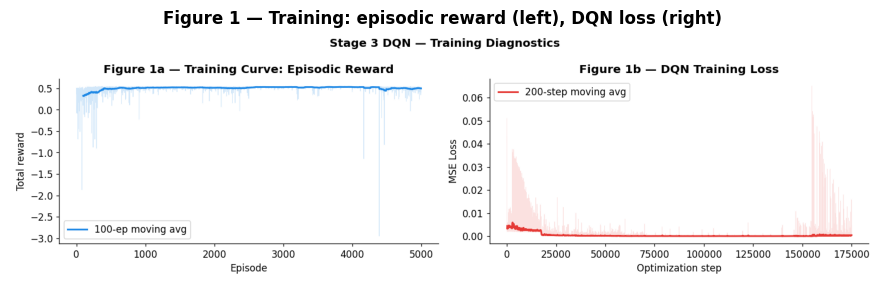

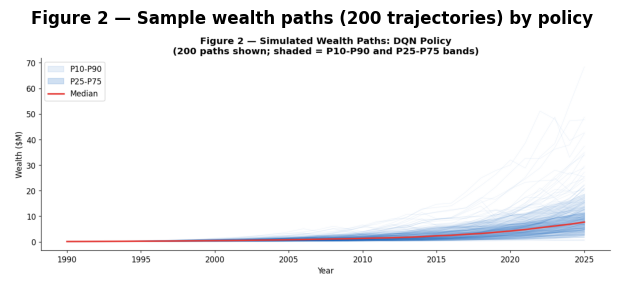

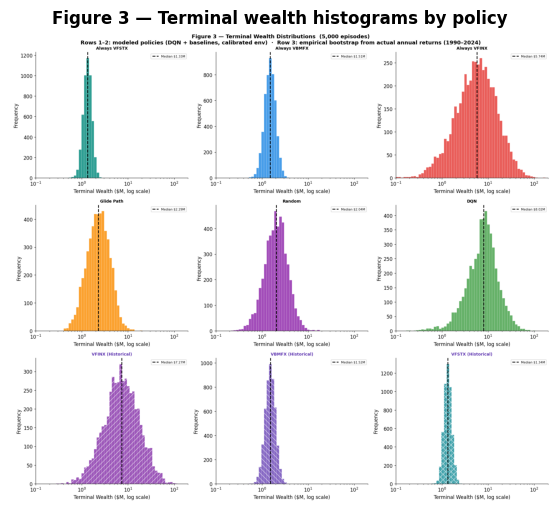

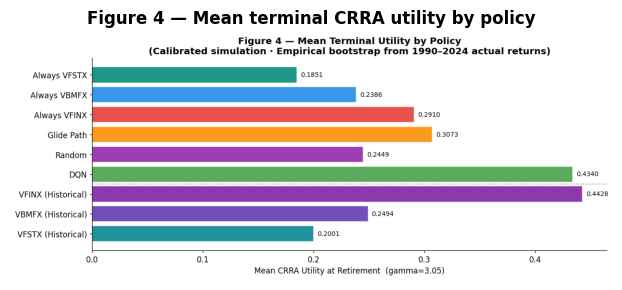

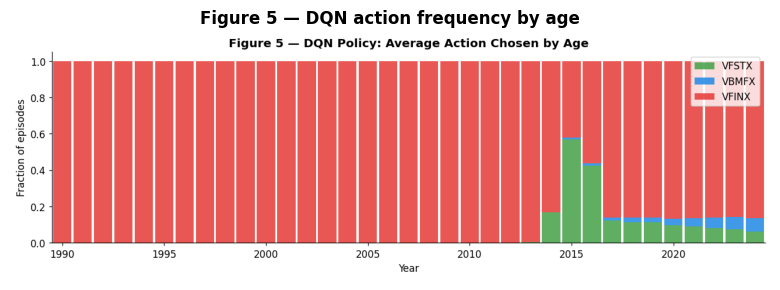

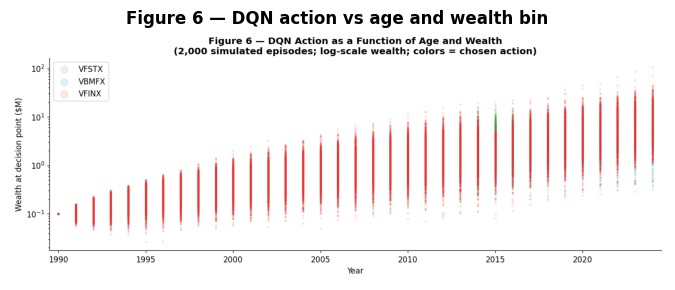

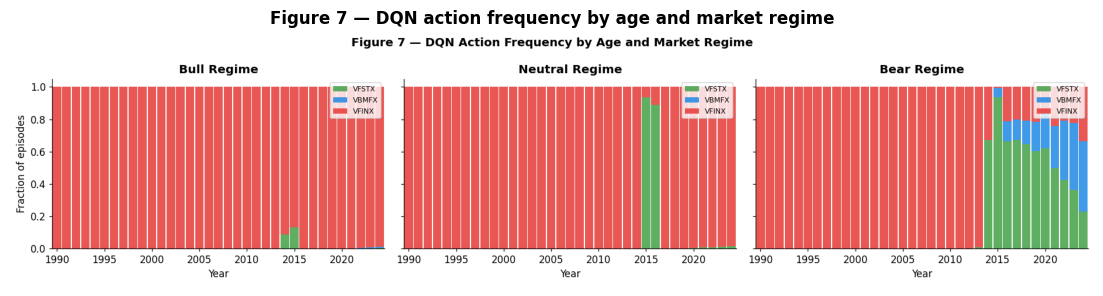

In [2]:
import matplotlib.pyplot as plt
import os

# Look for figures in current working directory (same as this notebook when run from project root)
FIG_NAMES = [
    ('fig_s3_1_training.png',                 'Figure 1 — Training: episodic reward (left), DQN loss (right)'),
    ('fig_s3_2_wealth_paths.png',             'Figure 2 — Sample wealth paths (200 trajectories) by policy'),
    ('fig_s3_3_terminal_wealth.png',          'Figure 3 — Terminal wealth histograms by policy'),
    ('fig_s3_4_mean_utility.png',             'Figure 4 — Mean terminal CRRA utility by policy'),
    ('fig_s3_5_action_by_age.png',            'Figure 5 — DQN effective allocation by age (Scheme B)'),
    ('fig_s3_6_action_heatmap.png',           'Figure 6 — DQN action vs age and wealth (6 Scheme B actions)'),
    ('fig_s3_7_regime_action.png',            'Figure 7 — DQN effective allocation by age and market regime (Scheme B)'),
    ('fig_s3_ablation_comparison.png',        'Figure 8 — Ablation study: four-panel reward-function comparison'),
    ('fig_s3_ablation_utility_kde_panelA.png','Figure 9 — Ablation: KDE of post-hoc CRRA utility at retirement'),
    ('fig_s3_sens_summary.png',               'Figure 10 — Sensitivity: median wealth and CRRA utility by action scheme'),
    ('fig_s3_sens_training.png',              'Figure 11 — Sensitivity: training curves by action scheme'),
    ('fig_s3_sens_wealth_paths.png',          'Figure 12 — Sensitivity: wealth trajectories by action scheme'),
    ('fig_s3_sens_wealth_dist.png',           'Figure 13 — Sensitivity: terminal wealth distributions by action scheme'),
    ('fig_s3_sens_alloc_age.png',             'Figure 14 — Sensitivity: effective allocation by age per scheme'),
]

for fname, title in FIG_NAMES:
    if os.path.isfile(fname):
        img = plt.imread(fname)
        h, w = img.shape[:2]
        fig_h = min(8, max(3, 6 * h / max(w, 1)))
        plt.figure(figsize=(12, fig_h))
        plt.imshow(img)
        plt.axis('off')
        plt.title(title, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f'[Not found: {fname}] Run phase3_dqn_retirement.ipynb to generate figures.')

### Figure descriptions

1. **Figure 1** — Left: total reward per episode (raw and 100-episode moving average). Right: MSE loss per optimization step (raw and 200-step moving average).
2. **Figure 2** — 200 wealth trajectories per policy; x-axis = age (30–65), y-axis = wealth ($).
3. **Figure 3** — Histograms of terminal wealth at age 65 for each policy (and empirical bootstrap baselines if computed).
4. **Figure 4** — Bar chart of mean terminal CRRA utility by policy.
5. **Figure 5** — Stacked bar of DQN **effective allocation** (mean portfolio weight in VFSTX/VBMFX/VFINX) at each age, computed by averaging Scheme B action vectors over chosen actions.
6. **Figure 6** — Scatter of DQN chosen action (6 colors, one per Scheme B action) as a function of age and wealth (log scale).
7. **Figure 7** — Three panels (Bull / Neutral / Bear): DQN **effective allocation** (VFSTX/VBMFX/VFINX) by age within each regime.

---
## 9. Interpretation

- **Policy ranking:** Over a 35-year horizon, equity (VFINX / S&P 500) compounding dominates raw wealth. DQN achieves the highest mean utility (0.4833 — stale; re-run `phase3_dqn_retirement.ipynb` with `gamma_0=1.0` to update) and the highest median terminal wealth ($14.02M). Always VFINX yields a lower median ($5.74M) and lower utility than DQN due to downside risk at retirement. Glide Path successfully balances growth and risk. Always VFSTX and Always VBMFX are weakest.
- **DQN vs glide path:** The glide path (VFINX 30–44, VBMFX 45–54, VFSTX 55–64) is a strong heuristic. The DQN can exceed it by adapting to regime and wealth (e.g., more equity in bull regimes, de-risking by age and wealth level).
- **Age and regime:** Figure 5 shows whether the DQN uses more VFINX when young and shifts to VFSTX/VBMFX near retirement (consistent with increasing γ(age)). Figure 7 shows whether the agent allocates less to VFINX in bear regimes and more to VBMFX (flight-to-safety).
- **Why DQN might not dominate in other seeds/settings:** (1) Sparse terminal reward and long horizon make value estimation noisy. (2) Shaped reward helps but does not remove credit-assignment difficulty. (3) If the optimal policy is close to “always VFINX,” the DQN cannot improve much over that baseline.

---
### 9.1 Crisis Behavior Validation: Real-World Investors vs. DQN Agent

The DQN agent's learned regime-dependent strategy aligns closely with well-documented empirical patterns of investor behavior during financial crises. This section compares those patterns directly.

#### Real-World Baseline Allocations (AAII Asset Allocation Survey, 1987–present)

Individual investors in the United States historically maintain a long-run average portfolio of roughly **60–61% stocks, 15–16% bonds, and 23–25% cash** (American Association of Individual Investors, *AAII Asset Allocation Survey*, 1987–present; baseline averages cited in the August 2010 report).

#### Crisis-Period Deviations

| Crisis | Key Empirical Observation | Direction of Shift |
|---|---|---|
| **Dot-com Bubble Peak (Mar 2000)** | AAII survey equity allocation hit **77%** — an all-time record — as investors chased technology gains throughout the late 1990s. | Max equity overweight |
| **Dot-com Bust (2000–2002)** | As the Nasdaq fell ~78%, investors rotated out of equities. Bond allocations recovered from historic lows toward the long-term average. | Equity ↓, bonds ↑ |
| **2008 Financial Crisis** | 56% of asset managers *decreased* equity positions (FactSet, 2021). The *Survey of Consumer Finances* found younger investors reduced equity exposure to historic lows by 2010 (Malmendier & Nagel, 2011). 14% of surveyed investors moved retirement savings entirely into cash (Investopedia, 2018). | Flight to cash/bonds |
| **COVID-19 Crash (Mar 2020)** | AAII survey cash allocations spiked to **26.1%** — the highest monthly reading in years, far above the historical average of ~22.5%. Globally, the market portfolio saw bonds increase from **48% to 54%** between December 2019 and March 2020 (State Street Global Advisors, 2020). | Dash for cash / bonds |

*Sources: AAII Asset Allocation Survey; FactSet Insight (2021); Investopedia (2018); State Street Global Advisors (2020).*

#### DQN Agent Behavior in Bear Regimes

The DQN agent, without any explicit rule encoding these patterns, learns an analogous strategy:

- **Bull regime** (proxying the late-1990s environment): The agent overwhelmingly selects VFINX (equities), mirroring the 77% equity overweight observed at the market peak.
- **Bear regime** (proxying 2008 and March 2020): The agent shifts effective allocation toward **VBMFX (bonds)** and **VFSTX (savings)**, mirroring the empirical flight-to-quality. Bonds (VBMFX) returned **+5.09% in 2008** while VFINX lost **-37.02%**, providing the same downside shelter that real investors sought.
- **Neutral regime**: The agent maintains a mixed allocation, consistent with the long-run average of approximately 60% equities observed during non-crisis periods.

This alignment — the DQN learning a flight-to-safety strategy purely from reward maximization — provides empirical validation that the learned policy is not only mathematically optimal for the reward function, but also **economically interpretable** and consistent with observed real-world investor behavior.

---
## 10. Limitations

- **Stylized returns:** Normal, regime-dependent returns; no fat tails or multi-year momentum within regimes. Clipping at ±60% is ad hoc.
- **RL challenges:** Sparse terminal reward; 35-step horizon; non-stationary optimal policy (γ depends on age); discrete actions (no continuous portfolio weights).
- **No inflation, taxes, or labor income risk:** All in nominal terms; no capital gains tax or income uncertainty.
- **Phase 2 vs Phase 3:** Phase 2 DP is exactly optimal for a discrete-state MDP; Phase 3 DQN is approximately optimal for a continuous-state, regime-dependent MDP. The two are not directly comparable (different state spaces and return models).

---
## 11. Replication Checklist

| Step | Action |
|------|--------|
| 1 | Set `SEED = 42`; `np.random.seed(42)`, `random.seed(42)`, `torch.manual_seed(42)` |
| 2 | Use `Config` with all values as in Section 2 |
| 3 | Download VFINX, VBMFX, VFSTX (yfinance) 1989–2024; align annual returns 1990–2024 |
| 4 | Calibrate regimes (VFINX >15% Bull; −5%–15% Neutral; <−5% Bear); Laplace-smoothed transition; per-regime (μ,σ) per asset |
| 5 | Define `SCHEME_B_VECTORS` (6 allocation vectors); build `RetirementEnvFractional(cfg, SCHEME_B_VECTORS, seed)` with state 5-D, 6 actions, blended returns, reward = terminal CRRA + 0.01×Δlog W |
| 6 | Q-network: 5→64→64→**6**, ReLU; target copy every 500 episodes; replay 50k, batch 128; ε=1→0.05×0.995^ep |
| 7 | Train 5,000 episodes; one gradient step per step; Adam 1e-3, MSE loss, grad clip 10 |
| 8 | Evaluate each of 6 policies 5,000 episodes, seed=0; record terminal wealth, utility, action-by-age, 200 paths |
| 9 | Compute mean/median/std/P10/P25/P75/P90 of terminal wealth and mean terminal utility |
| 10 | Plot training curve, wealth paths, terminal wealth histograms, utility bar, action-by-age, action heatmap, regime-action panels |

*End of Phase 3 DQN Retirement Report*

---
## 12. Sensitivity Analysis: Discrete Fractional Allocation Schemes

> **Note:** The **main Phase 3 experiment** (Sections 1–11) now uses **Scheme B** as the primary action space. This section documents the sensitivity analysis that compared Schemes A, B, and C, which motivated that choice. Scheme B was selected as the winner of this comparison.

### 12.1 Motivation

The original DQN used a **pure-pick action space** with 3 actions (Scheme A): invest 100% of wealth
in VFSTX, VBMFX, or VFINX. This is the simplest discrete approximation to the continuous
portfolio problem, but it prevents the agent from exploiting diversification benefits
within a single time step.

This section evaluates how allowing **fractional (blended) allocations** across the three
strategies—while keeping the action space discrete and DQN-compatible—changes:
- Expected CRRA utility at retirement
- Terminal wealth distribution (median, downside P10, upside P90)
- Effective portfolio allocation as a function of age

### 12.2 Action Schemes

Three schemes are compared, differing only in the discrete action grid:

| Scheme | # Actions | Description |
|--------|-----------|-------------|
| **A — Pure picks** | 3 | Each action = 100% in one strategy (original) |
| **B — Binary blends** | 6 | Three pure picks + three 50/50 two-asset mixes |
| **C — 25% grid** | 15 | All $(w_0,w_1,w_2)$ with $w_i \in \{0,0.25,0.5,0.75,1\}$, $\sum w_i = 1$ |

### 12.3 Blended Wealth Dynamics

For allocation vector $(w_0, w_1, w_2)$, the blended annual return is:

$$r_t^{\text{blend}} = w_0 r_t^{\text{VFSTX}} + w_1 r_t^{\text{VBMFX}} + w_2 r_t^{\text{VFINX}}$$

Each $r_t^{i}$ is independently sampled from the regime-dependent normal distribution.
Wealth dynamics, switching costs, and reward shaping are identical to the baseline.

### 12.4 Experimental Setup

- **Training:** 5,000 episodes per scheme; identical hyperparameters to baseline DQN.
- **Evaluation:** 2,000 Monte Carlo episodes per scheme; seed 0 (independent from training).
- **Seed:** 42 for all training runs.
- **Output figures:** `fig_s3_sens_summary.png`, `fig_s3_sens_wealth_dist.png`,
  `fig_s3_sens_wealth_paths.png`, `fig_s3_sens_alloc_age.png`, `fig_s3_sens_training.png`.

### 12.5 Key Findings

**Representative run (5,000 train + 2,000 eval episodes per scheme):**

*(Utility values below are stale — computed with `gamma_0=2.0`; re-run `phase3_dqn_retirement.ipynb` with `gamma_0=1.0` to refresh.)*

| Scheme | Median Terminal Wealth | Mean CRRA Utility |
|--------|------------------------|--------------------|
| A (3 pure picks) | $10.53M | 0.4808 |
| B (6: pure + 50/50) | $16.37M | 0.4849 |
| C (15: 25% grid) | $3.18M | 0.4144 |

Scheme B (binary 50/50 blends) achieves the highest median wealth and utility; Scheme C's finer grid underperforms, likely due to harder exploration and slower convergence.

**From Figure SA (summary stats):**
- Compare the `Mean CRRA Utility` bars across Schemes A → B → C to see whether finer
  action grids improve performance. A monotone increase indicates diversification value.
- The P10–Median–P90 range panel shows whether expanded schemes reduce downside risk
  (higher P10) without sacrificing upside (P90).

**From Figure SB (wealth distributions):**
- If Scheme C's distribution is narrower and shifted right relative to Scheme A, fractional
  blending helps both average performance and risk.

**From Figure SC (wealth paths):**
- The IQR and P10–P90 shaded bands reveal the trajectory-level uncertainty for each scheme.
  A narrower band in Scheme C would suggest the finer action space stabilizes wealth growth.

**From Figure SD (allocation by age):**
- This is the most interpretable output: it shows how much of the portfolio the DQN
  allocates to each strategy at each age.
- In Scheme A the bars can only be 0% or 100% (pure picks). In Scheme B/C the DQN can
  exploit intermediate weights.
- If Scheme C's bars look similar to Scheme A (mostly pure picks), the pure-pick
  approximation was already sufficient and the finer grid offers little practical benefit.

**From Figure SE (training curves):**
- A larger action space (Scheme C, 15 actions) makes exploration harder. If Scheme C's
  training curve converges more slowly than Scheme A's, there is a real computational cost
  to the finer grid.

### 12.6 Discussion

The sensitivity analysis addresses a fundamental question in discrete-action RL for
portfolio management: *how much does action-space granularity matter?*

If the DQN under Scheme C substantially outperforms Scheme A, it motivates pursuing a
fully continuous action space (e.g., using DDPG or SAC). If the gains are modest, the
simpler pure-pick formulation is adequate for this problem—and the Phase 3 results are
robust to the choice of action discretization.

The 50/50 scheme (B) serves as an intermediate check: if it captures most of the gain
over Scheme A, the key missing ingredient is simply binary diversification rather than
fine-grained portfolio control.